# **V-JEPA Inference Visualization on Open-Source Self-Driving Data**

Author: **Alejandro Meza Tudela**

**Objective**: This project analyzes the inference behavior and latent representations of the V-JEPA (Video Joint Embedding Predictive Architecture) when applied to autonomous driving scenarios.

**Model Configuration**: For this experiment, the model utilizes the pre-trained Vit-L/16 backbone with VideoMix2M weights, enabling robust spatio-temporal feature extraction without the need for manual supervision.


## **V-JEPA Paper Overview**

In this section, we provide a summary of the V-JEPA architecture, exploring how feature prediction serves as a stand-alone objective for unsupervised world modeling.

### **Architectural Overview**

V-JEPA moves away from the traditional Generative (Pixel-level) reconstruction and Invariance-based (Contrastive) learning.

The core components are the following:
- **Context Encoder ($E_\theta$)**: A Vision Transformer (ViT) that processes the visible "context" patches of a video (x).
- **Target Encoder ($E_{\theta'}$)**: A momentum-updated version of the context encoder. It produces the "ground truth" embeddings for the masked regions ($y$). Crucially, these weights are not updated via gradients but via an Exponential Moving Average (EMA) of the Context Encoder.
- **Predictor ($P_\phi$)**: A smaller Transformer that takes the context embeddings and a mask token ($z$) to predict the embeddings of the missing target regions.

![Example](https://miro.medium.com/v2/resize:fit:1098/0*d6TvbPrSQtUtITni.png)

### **The Prediction Task: Feature over Pixels**

The fundamental breakthrough of V-JEPA is without doubt the **Feature Prediction**. Rather than trying to reconstruct every noisy pixel, V-JEPA predicts the latent representation of masked video blocks. For this, a sophisticated Multi-Block masking strategy is needed.

Regarding the masking strategy, the main components are the following:

- **Target ($y$)**: Spatially continuous blocks are sampled and repeated across the entire temporal dimension.
- **Context ($x$)**: The remaining part of the video.
- **Masking Ratios**: V-JEPA employs an average masking ratio of ~90%.


This forces the model to develop a deep semantic understanding of motion and object persistence to "fill in" the massive gaps across the frames.




### **Network Parametrization & Efficiency**

V-JEPA typically uses large-scale Vision Transformers (e.g., ViT-H/16 or ViT-L/16) using 3D Tubelets (e.g., $2 \times 16 \times 16$ tokens).

Other characteristics are the following:
- **Training Speed**: Significantly shorter schedules compared to pixel-reconstruction methods (like MAE).
- **Label Efficiency**: High performance even with limited labeled data. As labels decrease, the gap between V-JEPA and pixel-prediction models widens.
- **Adaptability**: Versatile visual representations that perform well across downstream tasks without adapting model weights (frozen backbone).

### **Perfomance**

- **Fine-Grained Temporal Understanding**: V-JEPA outperformed State-of-the-Art models by +6% accuracy on SomethingSomething-v2, a task where motion direction and temporal sequence are vital.
- **Frozen Evaluation**: Under "attentive probing" (keeping the backbone frozen), V-JEPA is superior to pixel-prediction models, suggesting it learns more high-level semantic features rather than low-level textures.

### **Use Cases & Applications**

The architecture is well suited for the following tasks:

- **Action Recognition**: Identifying complex actions in video.
- **Spatio-Temporal Detection**: Tracking what is happening and where is happening during time.
- **Autonomous Systems**: It is a key component to build World Models, that understand how objects move and interact.
- **Low Resource Domains**: Solving tasks where only a few labeled samples are available.



### **Conclusion**

The V-JEPA paper concludes that feature prediction is an effective stand-alone objective for unsupervised video learning.

By predicting in latent space, the model ignores irrelevant visual noise and focuses on the underlying "physics" and semantics of the scene.

The result is a model that is not only more efficient to train but also more robust at understanding motion than large-scale image models or pixel-level video models.

## **V-JEPA Backbone Configuration (ViT-L/16)**

In [1]:
%%capture
import os
import time

import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.signal import savgol_filter
from IPython.display import clear_output

from google.colab import files

# Clone the official repository
!git clone https://github.com/facebookresearch/jepa.git
%cd jepa

# Install dependencies
!pip install -r requirements.txt

# Import and load the model
import torch
"""
Import the model based on your requirements
Available options:
- vit_tiny: embed_dim=192, depth=12, num_heads=3, mlp_ratio=4
- vit_small: embed_dim=384, depth=12, num_heads=6, mlp_ratio=4
- vit_base: embed_dim=768, depth=12, num_heads=12, mlp_ratio=4
- vit_large: embed_dim=1024, depth=24, num_heads=16, mlp_ratio=4
- vit_huge: embed_dim=1280, depth=32, num_heads=16, mlp_ratio=4
- vit_giant: embed_dim=1408, depth=40, num_heads=16, mlp_ratio=48/11
- vit_gigantic: embed_dim=1644, depth=48, num_heads=16, mlp_ratio=64/13
"""
from src.models.vision_transformer import vit_large # Adjust based on the model scale you need

In [2]:
#Download the model weights
"""
 Characteristic of the pretrained weights
 - model: ViT-L
 - path size: 2x16x16
 - resolution: 224x224
 - iterations: 90k
 - batch size: 3072
 - data: VideoMix2M
"""
!wget https://dl.fbaipublicfiles.com/jepa/vitl16/vitl16.pth.tar -O vjepa_vitl16.pth

--2026-05-05 11:15:47--  https://dl.fbaipublicfiles.com/jepa/vitl16/vitl16.pth.tar
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.249.182.39, 13.249.182.33, 13.249.182.81, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|13.249.182.39|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5143105394 (4.8G) [application/x-tar]
Saving to: ‘vjepa_vitl16.pth’

vjepa_vitl16.pth    100%[===================>]   4.79G   168MB/s    in 32s     

2026-05-05 11:16:19 (152 MB/s) - ‘vjepa_vitl16.pth’ saved [5143105394/5143105394]



In [3]:
import os
print(os.path.abspath("vjepa_vitl16.pth"))

/content/jepa/vjepa_vitl16.pth


In [4]:
# Set device
device = torch.cuda.current_device() if torch.cuda.is_available() else 'cpu'

# Initialize model
model = vit_large(
    img_size=224,
    patch_size=16,
    num_frames=16,
    tubelet_size=2
)

# Load the downloaded file
checkpoint_path = os.path.abspath("vjepa_vitl16.pth")
checkpoint = torch.load(checkpoint_path, map_location='cuda' if torch.cuda.is_available() else 'cpu')

# Handle the 'target_encoder' or 'model' key
if 'target_encoder' in checkpoint:
    state_dict = checkpoint['target_encoder']
elif 'model' in checkpoint:
    state_dict = checkpoint['model']
else:
    state_dict = checkpoint

# Remove 'module.' prefix if it was saved with DataParallel
state_dict = {k.replace('module.', '').replace('backbone.', ''): v for k, v in state_dict.items()}

# Load the weights
try:
    msg = model.load_state_dict(state_dict, strict=True)
    print("Model loaded successfully with no missing keys!")

    model.to(device)
    model.eval()
except RuntimeError as e:
    print(f"Still having issues: {e}")


Model loaded successfully with no missing keys!


## **Source Video Selection (BDD100K)**

For this demonstration, we utilize the **BDD100K** dataset, a large-scale, open-source benchmark for autonomous driving developed by the University of California, Berkeley. It is widely regarded as one of the most diverse and comprehensive datasets available in the domain.

The dataset comprises 100,000 video clips, each roughly 40 seconds long, captured at 720p and 30fps. Beyond raw video, the dataset includes GNSS/IMU telemetry, providing precise spatial context for driving trajectories.

Unlike more localized datasets, BDD100K offers exceptional spatio-temporal diversity, featuring data across various cities (New York, Berkeley, San Francisco, and the Bay Area), weather conditions, and times of day. This diversity is critical for testing the robustness of V-JEPA’s world-modeling capabilities across different environmental distributions.

https://bair.berkeley.edu/blog/2018/05/30/bdd/

![Example](https://i.ytimg.com/vi/IGi9K9FY35Y/maxresdefault.jpg)


In [5]:
#In this cell, we can try to upload our videos
uploaded = files.upload()
#As a demonstration, we have uploaded 2 videos
video_path = list(uploaded.keys())
print(f'Video has been uploaded!')

Saving cac32276-a70feba7.mov to cac32276-a70feba7.mov
Saving cadfb2fe-5dd5f809.mov to cadfb2fe-5dd5f809.mov
Video has been uploaded!


In [9]:
video_path = list(uploaded.keys())
video_path

['cac32276-a70feba7.mov', 'cadfb2fe-5dd5f809.mov']

## **V-JEPA Video Inference and Analysis**

In [10]:
def process_video_vjepa(path, window_size=16, stride=5, target_seconds=32):
    """
    Extracts spatio-temporal features using V-JEPA via a sliding window.

    Args:
        path (str): Path to the BDD100K video target file.
        window_size (int): Number of frames per V-JEPA tubelet block (temporal depth).
        stride (int): Frame jump between consecutive inferences (determines overlap).
        target_seconds (int): How much of the video to process.
    """
    cap = cv2.VideoCapture(path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames_to_read = int(fps * target_seconds)

    features = []
    representative_frames = [] #storage the video frames
    frame_buffer = []
    spatial_features = [] # To store (196, 1024) per window
    processed_count = 0

    # Start the global timer
    start_wall_time = time.perf_counter()

    print(f"Starting Extraction | Target: {target_seconds}s (~{total_frames_to_read} frames)")

    while cap.isOpened() and processed_count < total_frames_to_read:
        ret, frame = cap.read()
        if not ret:
            break

        processed_count += 1

        # 1. Prepare frame
        img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (224, 224))
        img_tensor = torch.from_numpy(img_resized).permute(2, 0, 1).float().div(255)
        frame_buffer.append(img_tensor)

        # 2. Run Inference
        if len(frame_buffer) == window_size:
            input_block = torch.stack(frame_buffer).permute(1, 0, 2, 3).unsqueeze(0).to(device)

            with torch.inference_mode():
                with torch.amp.autocast('cuda'):
                    feat = model(input_block)
                    if isinstance(feat, list): feat = feat[-1]

                features.append(feat.mean(dim=1).cpu().numpy().flatten())
                spatial_feat = feat.detach().cpu().numpy().squeeze(0)
                spatial_features.append(spatial_feat)

                # Resize for memory efficiency
                h, w = img_rgb.shape[:2]
                aspect = w / h
                viz_frame = cv2.resize(img_rgb, (int(480 * aspect), 480))
                representative_frames.append(viz_frame)

            # Slide window
            frame_buffer = frame_buffer[stride:]

            # Log progress every 50 inferences
            if len(features) % 50 == 0:
                elapsed = time.perf_counter() - start_wall_time
                percent = processed_count / total_frames_to_read
                print(f" {elapsed:.1f}s elapsed | Progress: {percent:.1%} | Features: {len(features)}")

    cap.release()
    total_duration = time.perf_counter() - start_wall_time
    print(f"\n Total time: {total_duration:.2f} seconds for {target_seconds}s of video.")
    return np.array(features), representative_frames,spatial_features


# Define list variables to save each video result


vjepa_features_videos=[] #save global features of target video windows
frames_to_show_videos=[] #save frames of the target videos
spatial_features_videos=[] #save the tokenized grid of the ViT

for video_target_path in video_path:
  vjepa_features, frames_to_show, spatial_features = process_video_vjepa(video_target_path, target_seconds=32)
  vjepa_features_videos.append(vjepa_features)
  frames_to_show_videos.append(frames_to_show)
  spatial_features_videos.append(spatial_features)
  print(f"{video_target_path} has been processed!")
  print()

Starting Extraction | Target: 32s (~963 frames)


/usr/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


 7.5s elapsed | Progress: 27.1% | Features: 50
 14.0s elapsed | Progress: 53.1% | Features: 100
 20.9s elapsed | Progress: 79.0% | Features: 150

 Total time: 25.96 seconds for 32s of video.
cac32276-a70feba7.mov has been processed!
Starting Extraction | Target: 32s (~964 frames)
 6.7s elapsed | Progress: 27.1% | Features: 50
 14.0s elapsed | Progress: 53.0% | Features: 100
 21.0s elapsed | Progress: 78.9% | Features: 150

 Total time: 26.67 seconds for 32s of video.
cadfb2fe-5dd5f809.mov has been processed!


### PCA Visualization

How does V-JEPA "see" a driving scene? By compressing the high-dimensional feature vectors into a 2-dimensional plane, we can visualize the latent path of the video in the "Latent Topology" graph. This projection highlights the continuity of the model's internal representations and identifies "semantic jumps" where the model detects significant changes in the environment or vehicle behavior.

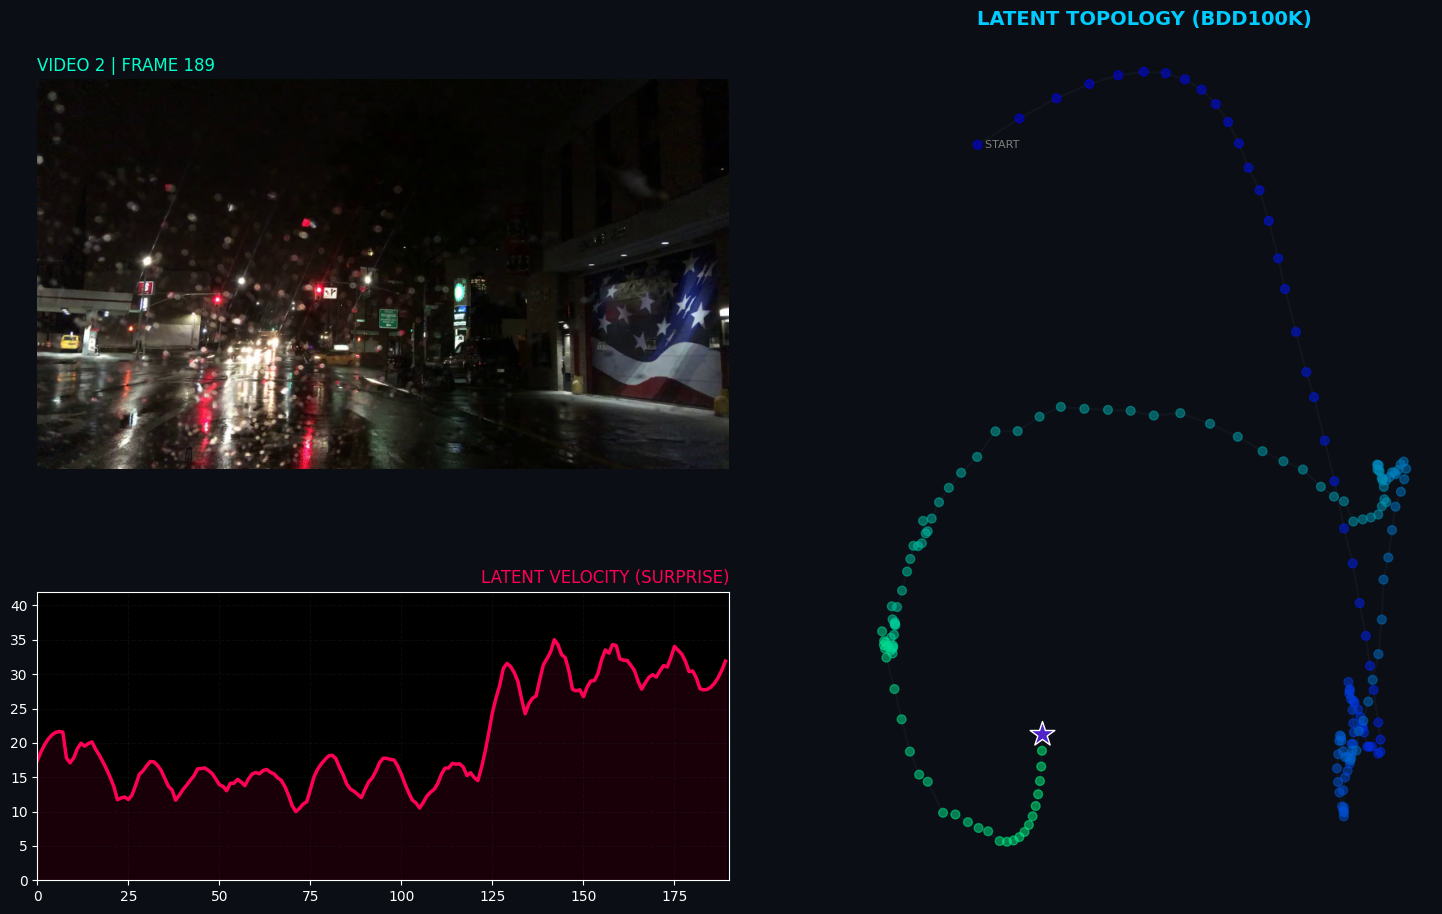

All video inferences visualized successfully.


In [28]:
# --- CONFIGURATION ---
# Set to True to see the 14x14 ViT heatmap, False for a cleaner dashboard
SHOW_SPATIAL = False
# ---------------------

plt.style.use('dark_background')

# Iteration through the list of processed videos ...
for v_idx in range(len(vjepa_features_videos)):

    # 1. Local Data Extraction
    # Pull the specific arrays for the current video in the list
    vjepa_features   = vjepa_features_videos[v_idx]
    frames_to_show   = frames_to_show_videos[v_idx]
    spatial_features = spatial_features_videos[v_idx]

    print(f"Processing Visualization for Video {v_idx + 1}/{len(vjepa_features_videos)}")
    time.sleep(1)

    # 2. Data Preparation (Video-Specific PCA)
    pca_global = PCA(n_components=3)
    # Standardize current video features
    scaled_feats = (vjepa_features - vjepa_features.mean(axis=0)) / (vjepa_features.std(axis=0) + 1e-8)
    reduced_3d = pca_global.fit_transform(scaled_feats)


    # Adjust window_length if the video is very short
    win_len = min(25, len(reduced_3d) // 2 * 2 - 1)
    if win_len > 3:
        for d in range(3):
            reduced_3d[:, d] = savgol_filter(reduced_3d[:, d], window_length=win_len, polyorder=3)

    # Normalize Global PCA to [0, 1] for RGB mapping
    rgb_min, rgb_max = reduced_3d.min(axis=0), reduced_3d.max(axis=0)
    rgb_colors = (reduced_3d - rgb_min) / (rgb_max - rgb_min + 1e-8)
    reduced_2d = reduced_3d[:, :2]

    # Calculate Motion Energy
    motion_energy = np.linalg.norm(np.diff(scaled_feats, axis=0), axis=1)
    motion_energy = np.insert(motion_energy, 0, 0)
    motion_energy = savgol_filter(motion_energy, window_length=min(15, win_len), polyorder=2)

    # 3. Spatial Feature Preparation (14x14 ViT Grid)
    s_feat_arr = np.array(spatial_features)
    # Shape: (Windows, 8, 196, 1024) -> Mean across temporal tubelets -> (Windows, 196, 1024)
    spatial_2d = s_feat_arr.reshape(s_feat_arr.shape[0], 8, 196, -1).mean(axis=1)

    pca_spatial = PCA(n_components=3)
    flat_spatial = spatial_2d.reshape(-1, spatial_2d.shape[-1])
    pca_spatial.fit(flat_spatial[::10])
    spatial_rgb = pca_spatial.transform(flat_spatial).reshape(-1, 14, 14, 3)

    # Scale Spatial RGB
    for d in range(3):
        s_min, s_max = spatial_rgb[..., d].min(), spatial_rgb[..., d].max()
        spatial_rgb[..., d] = (spatial_rgb[..., d] - s_min) / (s_max - s_min + 1e-8)

    # 4. Dashboard set-up
    # Dynamic layout based on SHOW_SPATIAL
    if SHOW_SPATIAL: #show semantic graph to
        fig = plt.figure(figsize=(22, 11), facecolor='#0B0E14')
        gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 1.2], height_ratios=[1, 0.6])
        ax_vid   = fig.add_subplot(gs[0, 0])
        ax_feat  = fig.add_subplot(gs[0, 1])
        ax_pulse = fig.add_subplot(gs[1, 0:2])
        ax_map   = fig.add_subplot(gs[:, 2])
    else:
        fig = plt.figure(figsize=(18, 11), facecolor='#0B0E14')
        gs = fig.add_gridspec(2, 2, width_ratios=[1.2, 1], height_ratios=[1, 0.6])
        ax_vid   = fig.add_subplot(gs[0, 0])
        ax_pulse = fig.add_subplot(gs[1, 0])
        ax_map   = fig.add_subplot(gs[:, 1])

    # 5. Plot
    for i in range(len(reduced_2d)):
        ax_vid.clear(); ax_map.clear(); ax_pulse.clear()
        if SHOW_SPATIAL: ax_feat.clear()

        # --- Top Row: Visuals ---
        ax_vid.imshow(frames_to_show[i])
        ax_vid.set_title(f"VIDEO {v_idx+1} | FRAME {i:03d}", color='#00FFCC', loc='left', fontsize=12)
        ax_vid.axis('off')

        if SHOW_SPATIAL:
            ax_feat.imshow(spatial_rgb[i], interpolation='bilinear')
            ax_feat.set_title("V-JEPA SPATIAL SEMANTICS", color='#FF0055', loc='left', fontsize=12)
            ax_feat.axis('off')

        # --- Bottom Row: Semantic Pulse ---
        ax_pulse.plot(motion_energy[:i+1], color='#FF0055', lw=2.5)
        ax_pulse.fill_between(range(i+1), motion_energy[:i+1], color='#FF0055', alpha=0.1)
        ax_pulse.set_xlim(0, len(motion_energy))
        ax_pulse.set_ylim(0, np.max(motion_energy) * 1.2)
        ax_pulse.set_title("LATENT VELOCITY (SURPRISE)", color='#FF0055', loc='right')
        ax_pulse.grid(color='#1A222F', linestyle='--', alpha=0.3)

        # --- Right Side: Topology Map ---
        # Draw a faint "Ghost Path" of the entire video for context
        ax_map.plot(reduced_2d[:, 0], reduced_2d[:, 1], color='#1A222F', lw=1.5, zorder=1, alpha=0.4)

        # History Trail
        ax_map.scatter(reduced_2d[:i+1, 0], reduced_2d[:i+1, 1],
                       c=range(i+1), cmap='winter', s=40, alpha=0.5, zorder=2)

        # Orientations Markers
        ax_map.text(reduced_2d[0, 0], reduced_2d[0, 1], '  START', color='gray', fontsize=8, verticalalignment='center')

        # Current Head
        ax_map.scatter(reduced_2d[i, 0], reduced_2d[i, 1],
                       color=rgb_colors[i], s=350, marker='*', edgecolors='white', zorder=5)

        ax_map.set_title("LATENT TOPOLOGY (BDD100K)", color='#00CCFF', fontsize=14, fontweight='bold')
        ax_map.axis('off')

        # Render current frame
        clear_output(wait=True)
        display(fig)
        time.sleep(0.01)

    plt.close(fig) # Clean up memory after each video

print("All video inferences visualized successfully.")

### Result interpretation & Conclusions

As we can see in the inference results, we have obtained 3 graphs:
- **Latent Topology**: A 2D  projection (via PCA) of the high-dimensional feature space. This map traces the video’s "semantic path," where proximity between points indicates similarity in the driving context. Transitions between clusters represent the model shifting between different environmental states.

- **Latent Velocity**:  A measure of the $L_2$ distance (Euclidean change) between consecutive temporal windows. This graph acts as a "semantic pulse," where peaks indicate high levels of "surprise" or new information. These spikes typically align with dynamic events—such as a vehicle cutting in, a change in lighting, or the car coming to a halt.

- **Spatial Semantics**: A $14 \times 14$ visualization of the model's tokenized grid. By projecting the internal features of each patch into RGB space, we reveal how the model differentiates between textures and objects (road, vehicles, sky) without any human-provided labels. However, its visualization has to been refined a little bit more.

Through these visualizations, we have successfully verified that V-JEPA’s latent space is highly sensitive to environmental dynamics. Specifically, the latent trajectory and velocity graphs show clear, measurable shifts in the model's state during critical transitions—such as when the vehicle comes to a complete stop or navigates an intersection. This confirms that the model is not merely "seeing" pixels, but correctly abstracting the underlying situational context of the driving scene.


**Next Steps**

While we have validated the richness of the encoded representations, the ultimate test of a world model is its ability to anticipate the future. The next phase of this research will focus on Forward Prediction—using these learned states to predict the next latent state of the environment. This will be covered in a V-JEPA 2 Analysis.